In [ ]:
# Import modules for plotting and analysis
import numpy as np
import matplotlib as mpl
import matplotlib.pylab as plt 
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline

mpl.style.use('~/mpl.style')

# Figure 2

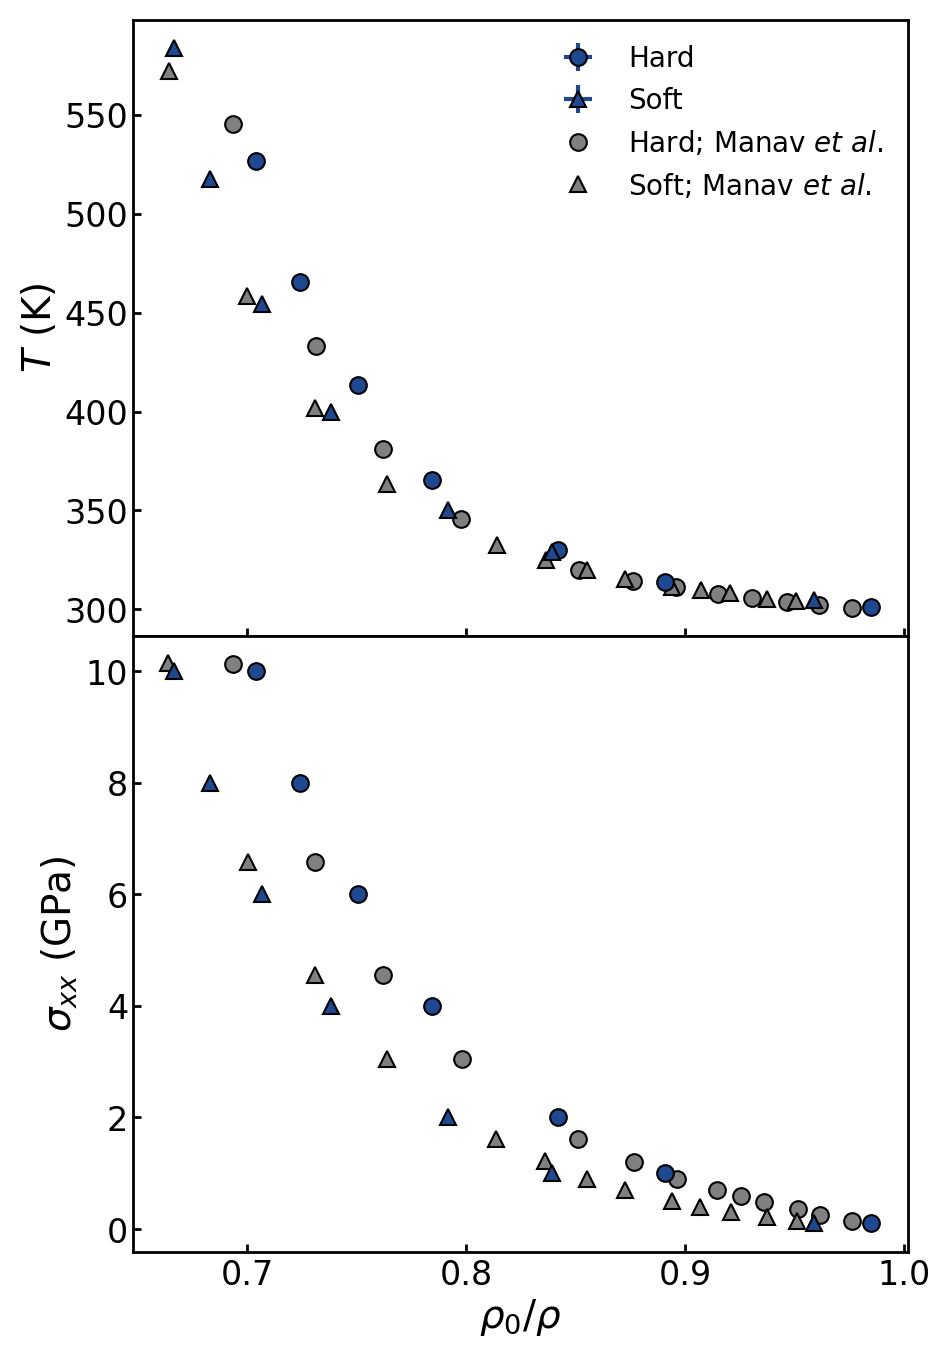

In [2]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex = True)

# Simulation Data
data = np.load('data/NPHugHugoniots.npy')

ax[0].errorbar(data[0,:,2,0], data[0,:,1,0], xerr = data[0,:,2,1], yerr = data[0,:,1,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Hard', zorder = 2)
ax[0].errorbar(data[1,:,2,0], data[1,:,1,0], xerr = data[1,:,2,1], yerr = data[1,:,1,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft', zorder = 2)

ax[1].errorbar(data[0,:,2,0], data[0,:,0,0], xerr = data[0,:,2,1], yerr = data[0,:,0,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)
ax[1].errorbar(data[1,:,2,0], data[1,:,0,0], xerr = data[1,:,2,1], yerr = data[1,:,0,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)


# Data reproduced from Manav and Ortiz. Polymer (2021) using WebPlotDigitizer
TH = np.load('data/Manav-2021/hardT.npy'); TS = np.load('data/Manav-2021/softT.npy')
PH = np.load('data/Manav-2021/hardP.npy'); PS = np.load('data/Manav-2021/softP.npy')

ax[0].errorbar(TH[0], TH[1], marker = 'o', mec = 'k', ls = '', c = 'grey', label = 'Hard; Manav $et\ al.$', zorder = 1)
ax[0].errorbar(TS[0], TS[1], marker = '^', mec = 'k', ls = '', c = 'grey', label = 'Soft; Manav $et\ al.$', zorder = 1)

ax[1].errorbar(PH[0], PH[1], marker = 'o', mec = 'k', ls = '', c = 'grey', zorder = 1)
ax[1].errorbar(PS[0], PS[1], marker = '^', mec = 'k', ls = '', c = 'grey', zorder = 1)

###

ax[1].set_xlabel(r'$\rho_0/\rho$')
ax[0].set_ylabel('$T$ (K)'); ax[1].set_ylabel('$\sigma_{xx}$ (GPa)')
ax[0].legend()

plt.subplots_adjust(hspace=0)

# Figure 3

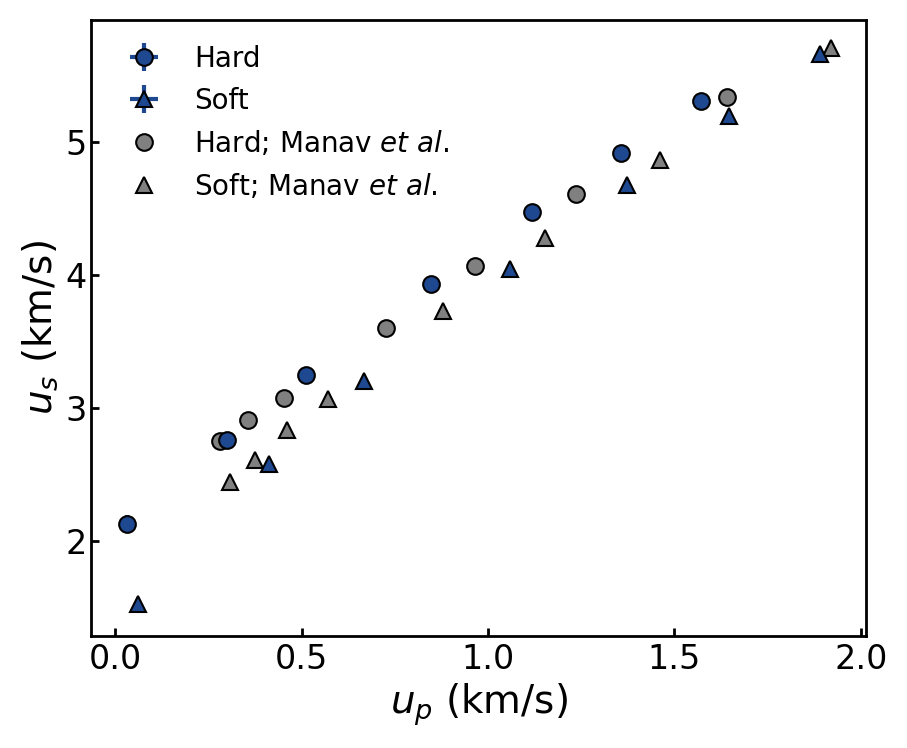

In [3]:
# Simulation Data
data = np.load('data/NPHugHugoniots.npy')

plt.errorbar(data[0,:,3,0], data[0,:,4,0], xerr = data[0,:,3,1], yerr = data[0,:,4,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Hard', zorder = 2)
plt.errorbar(data[1,:,3,0], data[1,:,4,0], xerr = data[1,:,3,1], yerr = data[1,:,4,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft', zorder = 2)


# Data reproduced from Manav and Ortiz. Polymer (2021) using WebPlotDigitizer
UH = np.load('data/Manav-2021/hardU.npy'); US = np.load('data/Manav-2021/softU.npy')

plt.errorbar(UH[0], UH[1], marker = 'o', mec = 'k', ls = '', c = 'grey', label = 'Hard; Manav $et\ al.$', zorder = 1)
plt.errorbar(US[0], US[1], marker = '^', mec = 'k', ls = '', c = 'grey', label = 'Soft; Manav $et\ al.$', zorder = 1)

###

plt.xlabel('$u_p$ (km/s)'); plt.ylabel('$u_s$ (km/s)')
plt.legend()

# Figure 4 (Raw Data)

Text(0, 0.5, '$t$ (0.1 ps)')

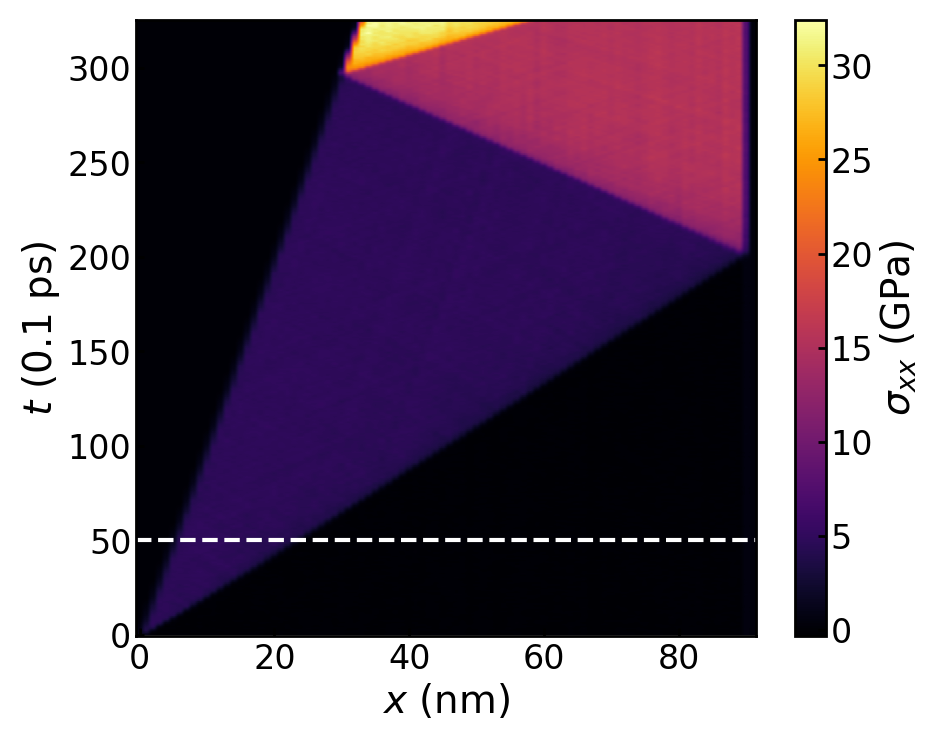

In [4]:
data = np.load('data/heatMap.npy', allow_pickle=True)

plt.imshow(data, cmap = 'inferno', aspect = 'auto', origin = 'lower')
plt.axhline(50, linestyle = '--', color = 'white')

###

cbar = plt.colorbar()
cbar.set_label('$\sigma_{xx}$ (GPa)')

plt.xlabel('$x$ (nm)'); plt.ylabel('$t$ (0.1 ps)')

# Figure 5

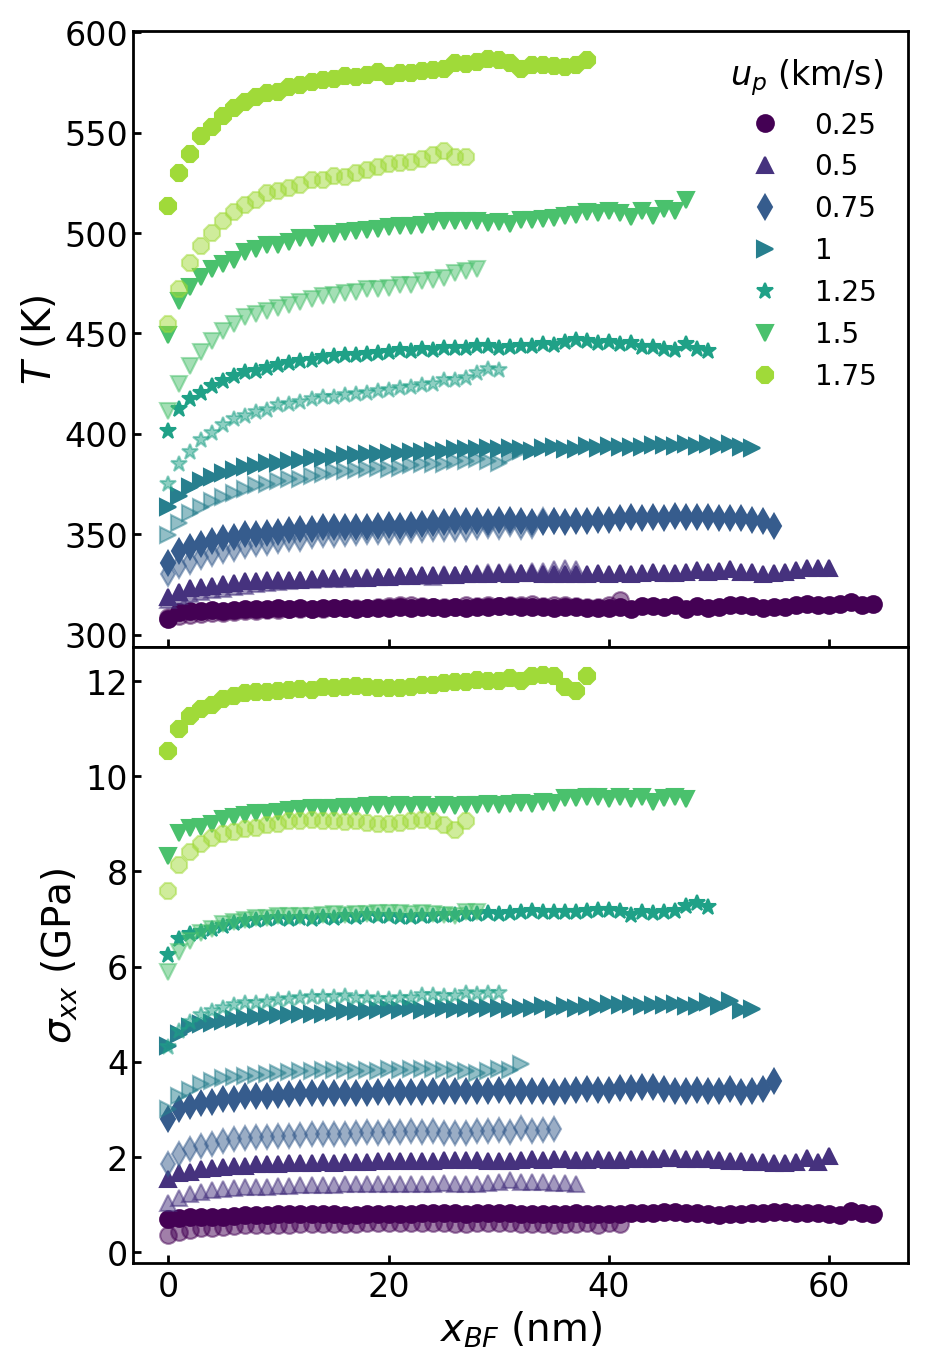

In [5]:
fig, ax = plt.subplots(2, 1, figsize = (10, 16), sharex=True)

ups = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75]
symbols = ['o', '^', 'd', '>', '*', 'v', '8']

for i in range(len(ups)):
    # Hard Phase
    data = np.load('data/Impact/hard/{:s}/binnedT.npy'.format(str(ups[i])))
    ax[0].plot(data[0], data[2], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])))

    data = np.load('data/Impact/soft/{:s}/binnedT.npy'.format(str(ups[i])))
    ax[0].plot(data[0], data[2], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)), alpha = 0.5)

    # Soft Phase
    data = np.load('data/Impact/hard/{:s}/binnedSigXX.npy'.format(str(ups[i])))
    ax[1].plot(data[0], data[2], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)))

    data = np.load('data/Impact/soft/{:s}/binnedSigXX.npy'.format(str(ups[i])))
    ax[1].plot(data[0], data[2], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)), alpha = 0.5)

###

ax[1].set_xlabel('$x_{BF}$ (nm)')
ax[0].set_ylabel('$T$ (K)'); ax[1].set_ylabel('$\sigma_{xx}$ (GPa)')
ax[0].legend(title = '$u_p$ (km/s)')

plt.subplots_adjust(hspace=0, wspace=0)

# Figure 6

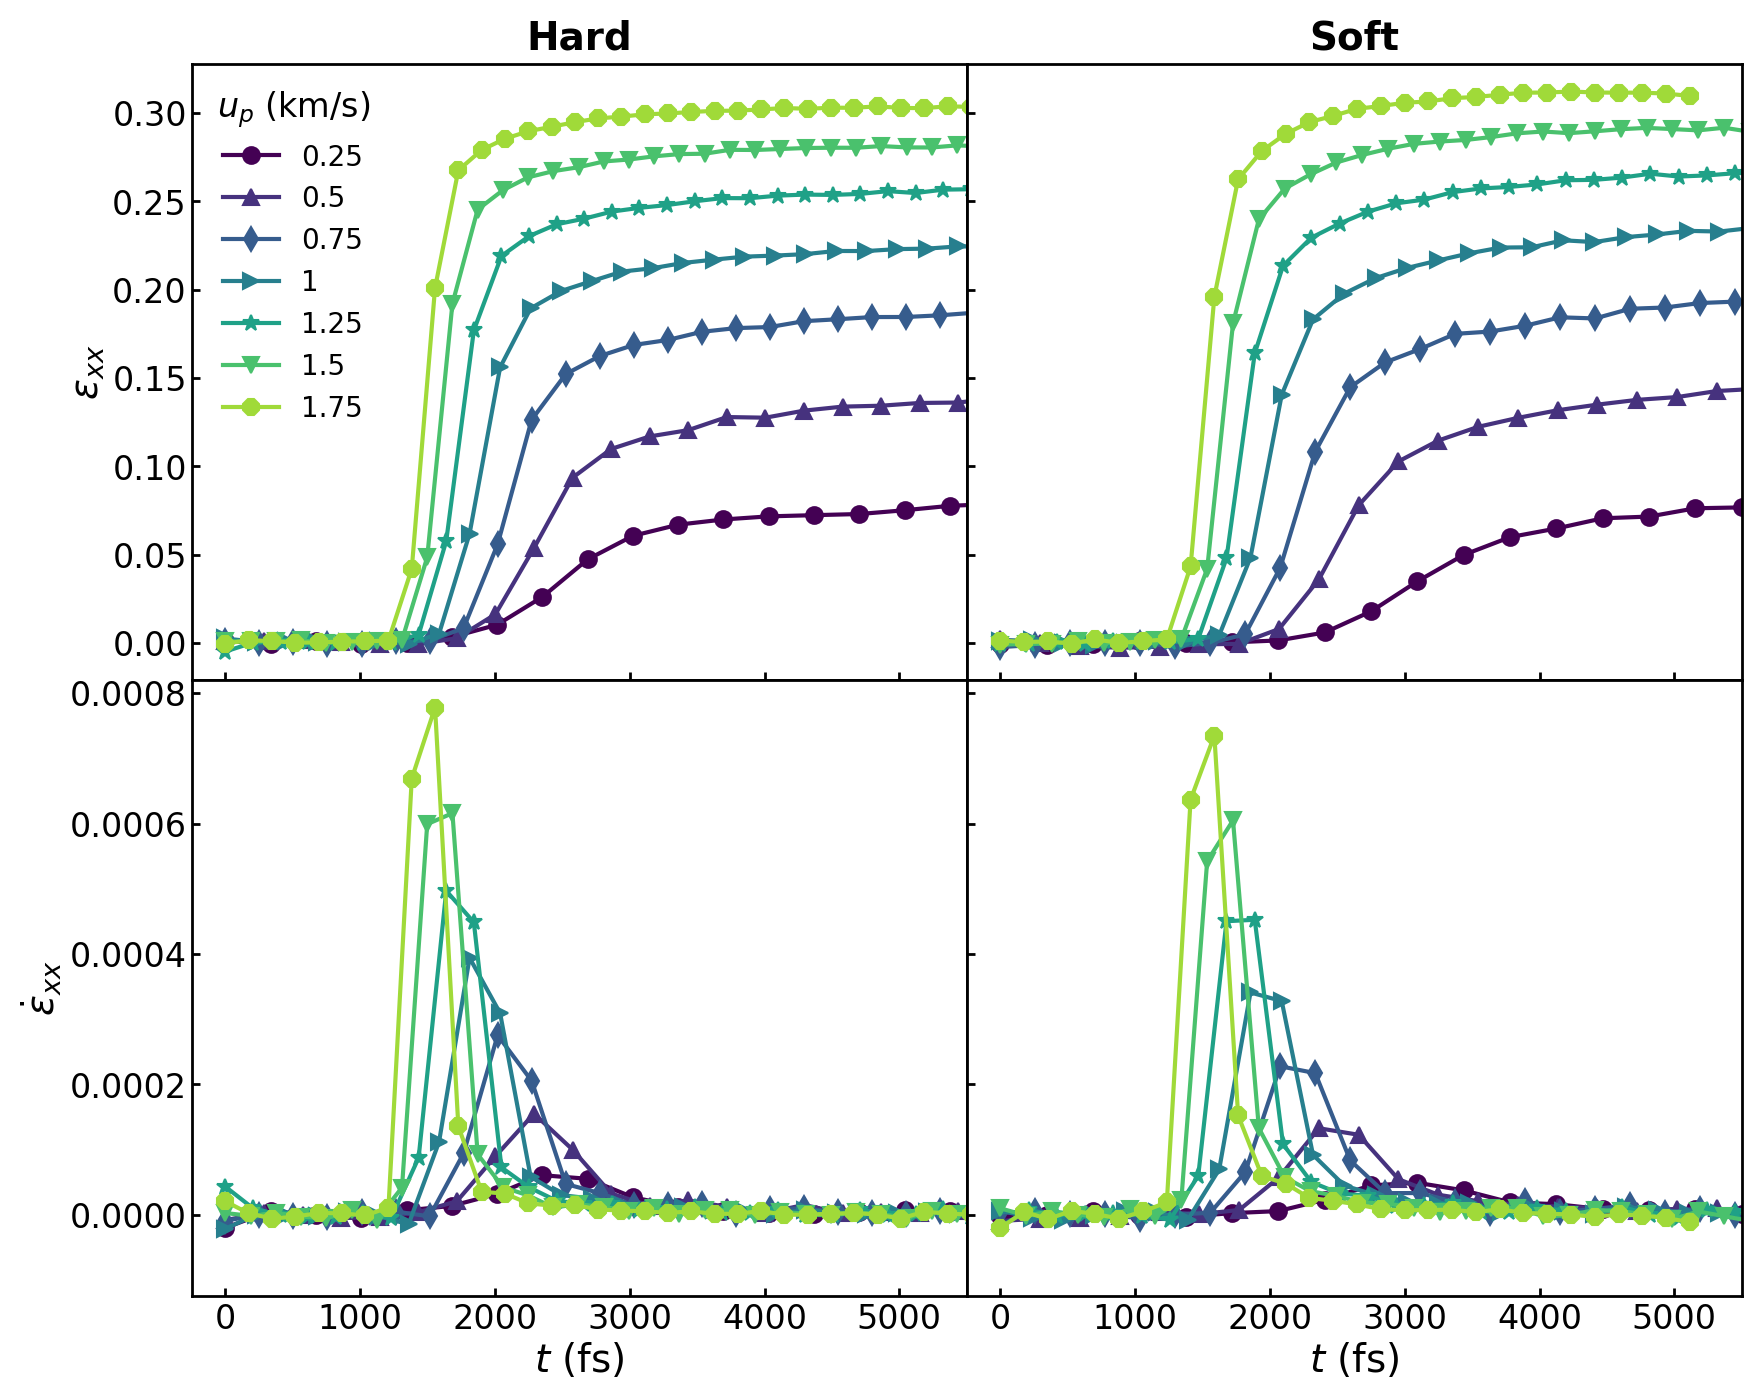

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(20, 16), sharex=True, sharey='row')

ups = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75]
symbols = ['o', '^', 'd', '>', '*', 'v', '8']

for i in range(len(ups)):
    # Hard Phase
    data = np.load('data/Impact/hard/{:s}/eps.npy'.format(str(ups[i])))

    us = np.load('data/Impact/hard/{:s}/us.npy'.format(str(ups[i])))/100 # us in A/fs
    data[0] *= 10 # x in A
    t = data[0]/us # t in fs

    # Strain
    ax[0,0].plot(t, data[1], marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])))

    # Strain Rate
    spl = UnivariateSpline(t, data[1], k = 3, s = 0)
    ax[1,0].plot(t, spl.derivative()(t), marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)))


    # Soft Phase
    data = np.load('data/Impact/soft/{:s}/eps.npy'.format(str(ups[i])))

    us = np.load('data/Impact/soft/{:s}/us.npy'.format(str(ups[i])))/100 # us in A/fs
    data[0] *= 10 # x in A
    t = data[0]/us # t in fs

    # Strain
    ax[0,1].plot(t, data[1], marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)))

    # Strain Rate
    spl = UnivariateSpline(t, data[1], k = 3, s = 0)
    ax[1,1].plot(t, spl.derivative()(t), marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)))

###

plt.xlim([-250, 5500])

ax[1,1].set_xlabel('$t$ (fs)'); ax[1,0].set_xlabel('$t$ (fs)')
ax[0,0].set_ylabel('$\epsilon_{xx}$'); ax[1,0].set_ylabel(r'$\dot{\epsilon}_{xx}$')
ax[0,0].legend(title = '$u_p$ (km/s)')

ax[0,0].set_title('Hard', weight = 'bold', pad = 10); ax[0,1].set_title('Soft', weight = 'bold', pad = 10)

plt.subplots_adjust(hspace=0, wspace=0)

# Figure 7

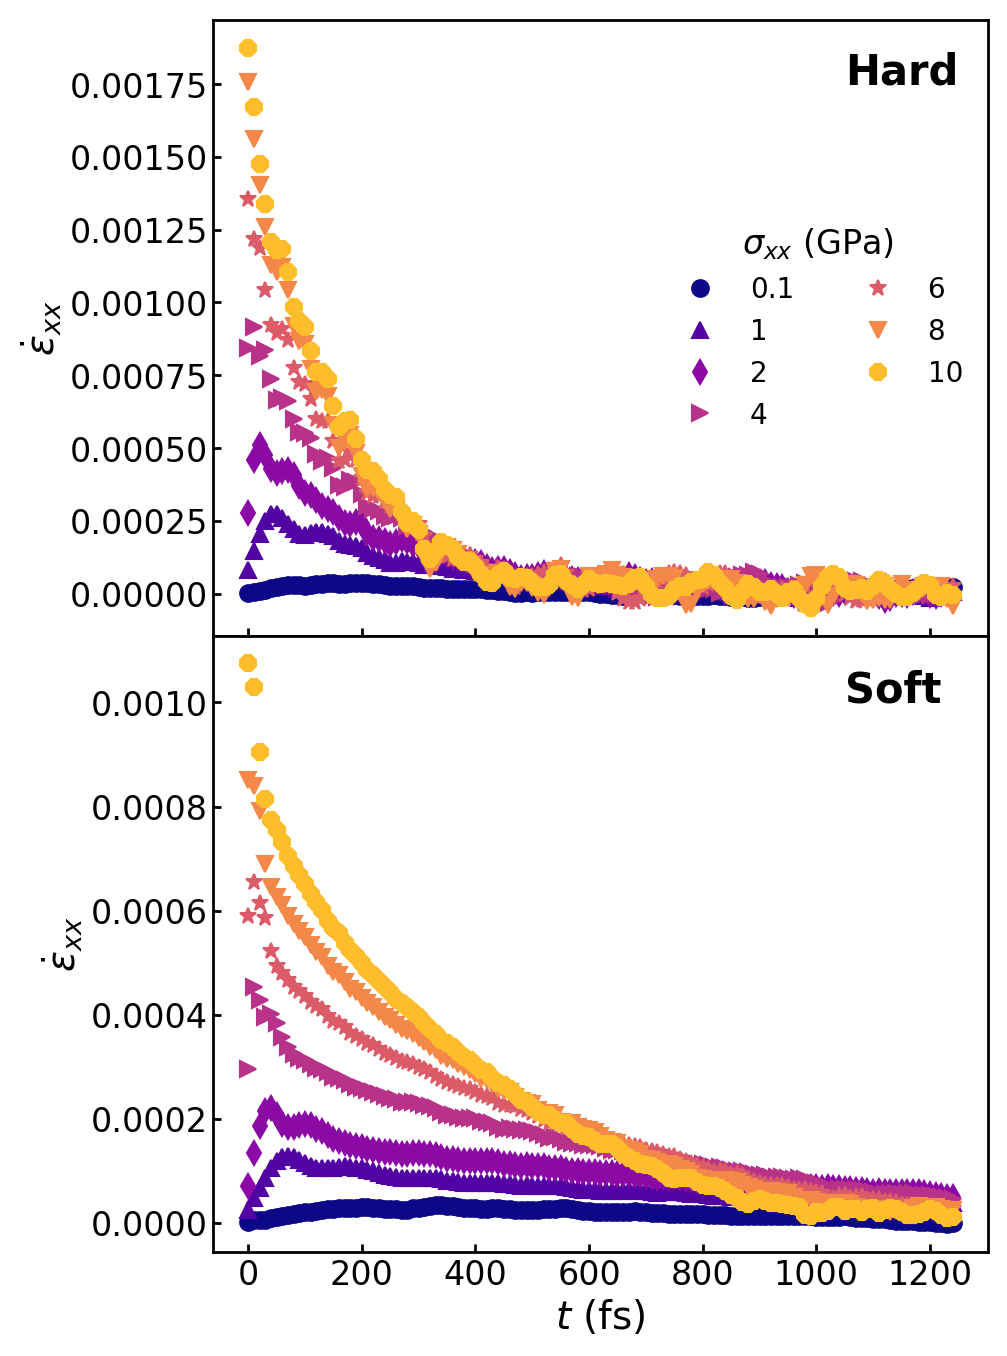

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

Ps = np.array([0.1, 1, 2, 4, 6, 8, 10], dtype = str)
symbols = ['o', '^', 'd', '>', '*', 'v', '8']

cutoff = 125

for i in range(len(Ps)):
    # Hard Phase
    data = np.load('data/NPHug/hard/{:s}/eps.npy'.format(str(Ps[i])))
    ax[0].plot(data[0,:cutoff], data[2,:cutoff], marker = symbols[i], ls = '', c = cm.plasma(i/len(Ps)), label = Ps[i])

    # Soft Phase
    data = np.load('data/NPHug/soft/{:s}/eps.npy'.format(str(Ps[i])))
    ax[1].plot(data[0,:cutoff], data[2,:cutoff], marker = symbols[i], ls = '', c = cm.plasma(i/len(Ps)), label = Ps[i])

###

ax[0].text(1050, 0.00175, 'Hard', fontsize = 30, weight='bold')
ax[1].text(1050, 0.001, 'Soft', fontsize = 30, weight='bold')

ax[1].set_xlabel('$t$ (fs)')
ax[0].set_ylabel(r'$\dot{\epsilon}_{xx}$'); ax[1].set_ylabel(r'$\dot{\epsilon}_{xx}$')
ax[0].legend(title = '$\sigma_{xx}$ (GPa)', ncol = 2, loc = 'center right')

plt.subplots_adjust(hspace=0)

# Figure 8

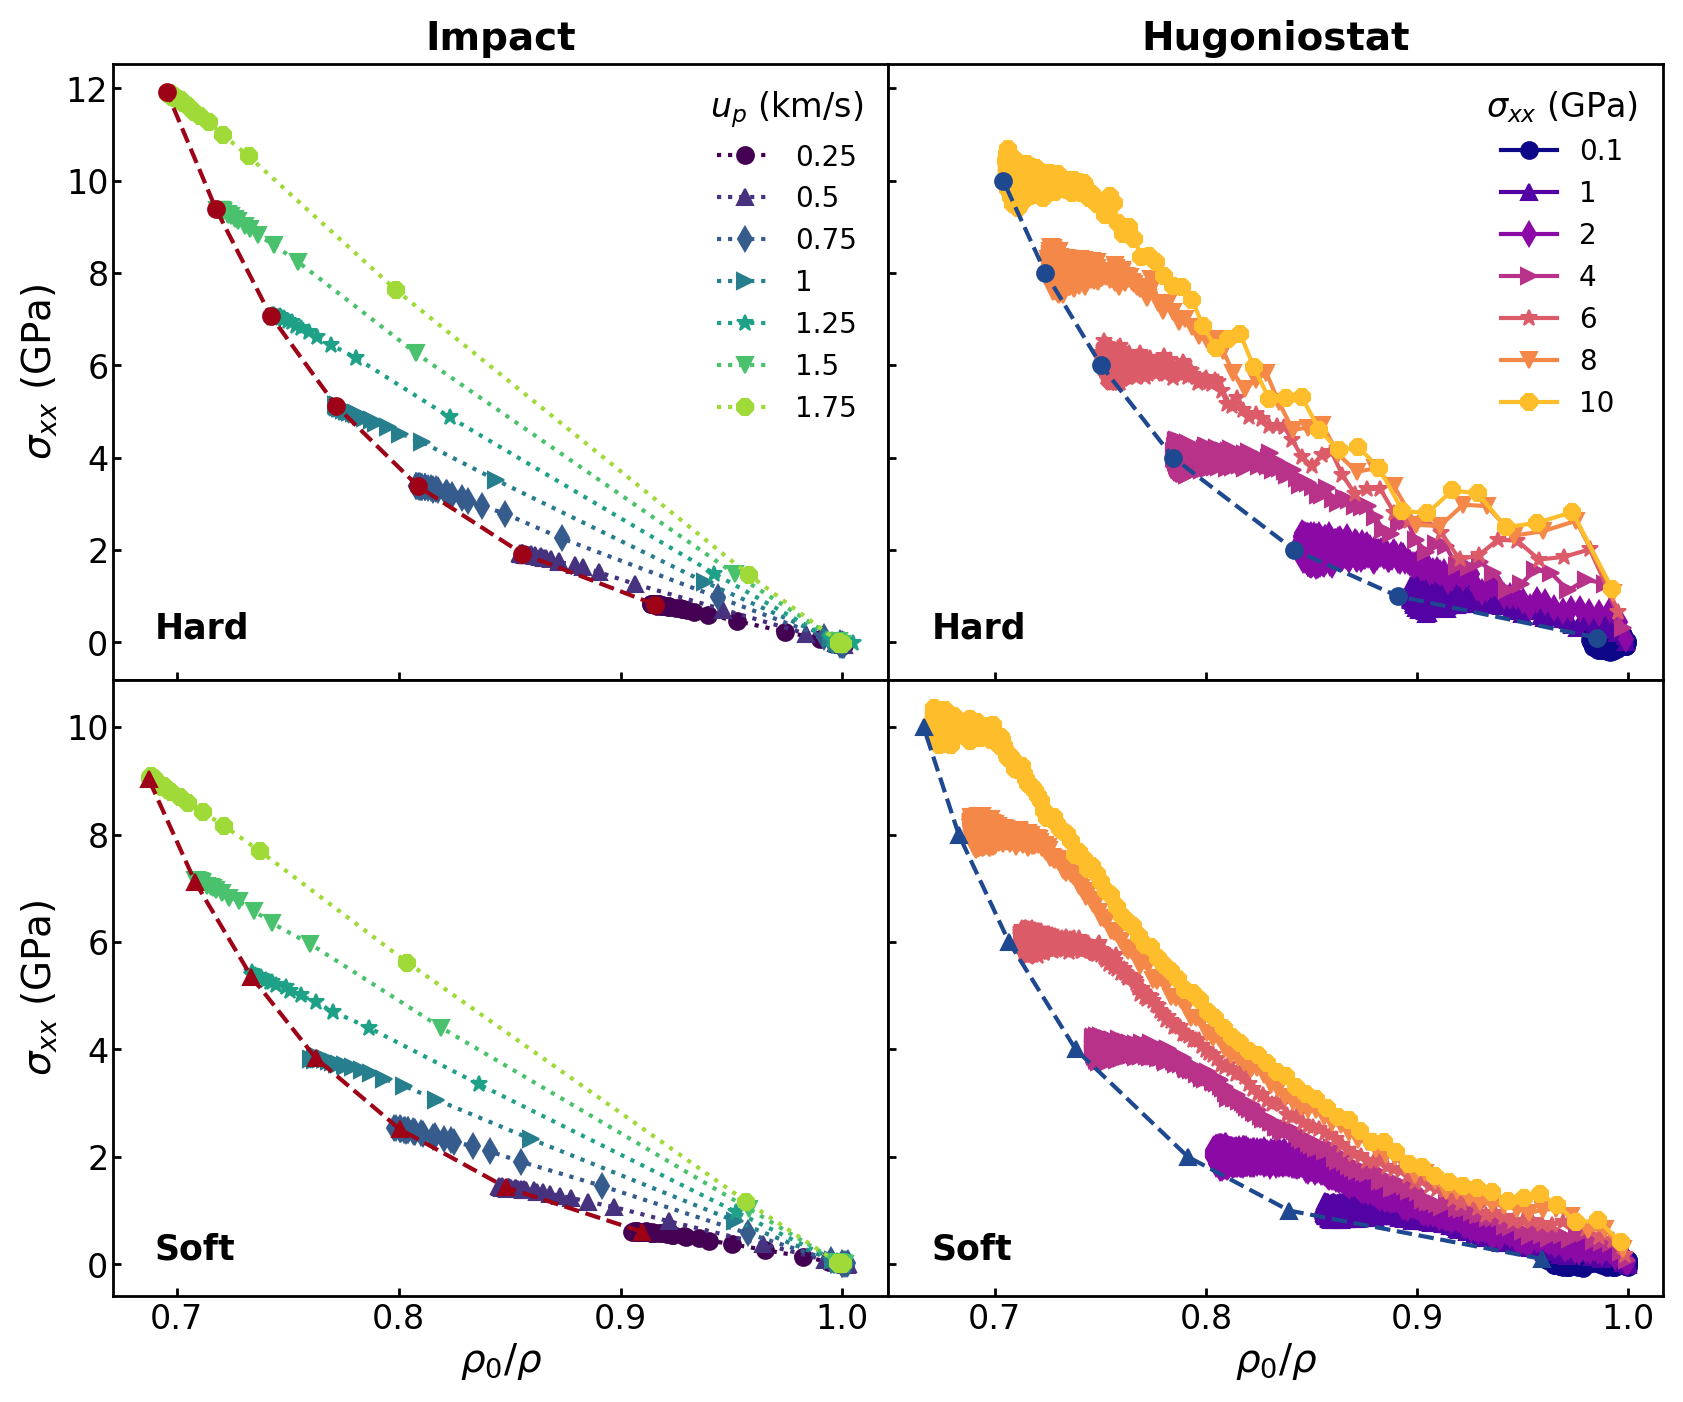

In [8]:
fig, ax = plt.subplots(2, 2,figsize = (20, 16), sharex='col', sharey = 'row')

rho0h = 1.2004; rho0s = 0.9352 # Quiescent densities in g/cm^3

# Impact
ups = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75]
symbols = ['o', '^', 'd', '>', '*', 'v', '8']
 
## Trajectories
for i in range(len(ups)):
    # Hard Phase
    sig = np.load('data/Impact/hard/{:s}/binnedSigXX_full.npy'.format(str(ups[i])))[2]
    rho = np.load('data/Impact/hard/{:s}/binnedRho_full.npy'.format(str(ups[i])))[2]

    cutoff = 20
    ax[0,0].plot(rho0h/rho[:-cutoff], sig[:-cutoff], marker = symbols[i], ls = 'dotted', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])))

    # Soft Phase
    sig = np.load('data/Impact/soft/{:s}/binnedSigXX_full.npy'.format(str(ups[i])))[2]
    rho = np.load('data/Impact/soft/{:s}/binnedRho_full.npy'.format(str(ups[i])))[2]

    cutoff = 5
    ax[1,0].plot(rho0s/rho[:-cutoff], sig[:-cutoff], marker = symbols[i], ls = 'dotted', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])))

## Shock Hugoniots
data = np.load('data/impactHugoniots.npy')
ax[0,0].plot(rho0h/data[0,2], data[0,1], marker = 'o', ls = '--', color = 'xkcd:carmine')
ax[0,0].scatter(1, 0, c = 'k')

ax[1,0].plot(rho0s/data[1,2], data[1,1], marker = '^', ls = '--', color = 'xkcd:carmine')
ax[1,0].scatter(1, 0, c = 'k')


# NPHug
Ps = np.array([0.1, 1, 2, 4, 6, 8, 10], dtype = str)

## Trajectories
data = np.load('data/NPHugTrajectories.npy')
for i in range(len(Ps)):
    Pxx = data[:,i,:,0] * 101325/10**9 # GPa
    rho = data[:,i,:,1]

    ax[0,1].plot(rho0h/rho[0], Pxx[0], marker = symbols[i], c = cm.plasma(i/len(Ps)), label = Ps[i])
    ax[1,1].plot(rho0s/rho[1], Pxx[1], marker = symbols[i], c = cm.plasma(i/len(Ps)))

## Shock Hugoniots
data = np.load('data/NPHugHugoniots.npy')
ax[0,1].plot(data[0,:,2,0], data[0,:,0,0], marker = 'o', ls = '--', c = 'xkcd:cobalt')
ax[1,1].plot(data[1,:,2,0], data[1,:,0,0], marker = '^', ls = '--', c = 'xkcd:cobalt')

###

ax[0,0].text(0.69, 0.1, 'Hard', fontsize = 25, weight='bold')
ax[1,0].text(0.69, 0.1, 'Soft', fontsize = 25, weight='bold')
ax[0,1].text(0.67, 0.1, 'Hard', fontsize = 25, weight='bold')
ax[1,1].text(0.67, 0.1, 'Soft', fontsize = 25, weight='bold')

ax[1,0].set_xticks([0.7, 0.8, 0.9, 1]); ax[1,1].set_xticks([0.7, 0.8, 0.9, 1])

ax[1,0].set_xlabel(r'$\rho_0/\rho$'); ax[1,1].set_xlabel(r'$\rho_0/\rho$')
ax[0,0].set_ylabel('$\sigma_{xx}$ (GPa)'); ax[1,0].set_ylabel('$\sigma_{xx}$ (GPa)')

ax[0,0].legend(title = '$u_p$ (km/s)')
ax[0,1].legend(title = '$\sigma_{xx}$ (GPa)')

ax[0,0].set_title('Impact', weight = 'bold', pad = 10); ax[0,1].set_title('Hugoniostat', weight = 'bold', pad = 10)

plt.subplots_adjust(hspace=0, wspace=0)

# Figure 9

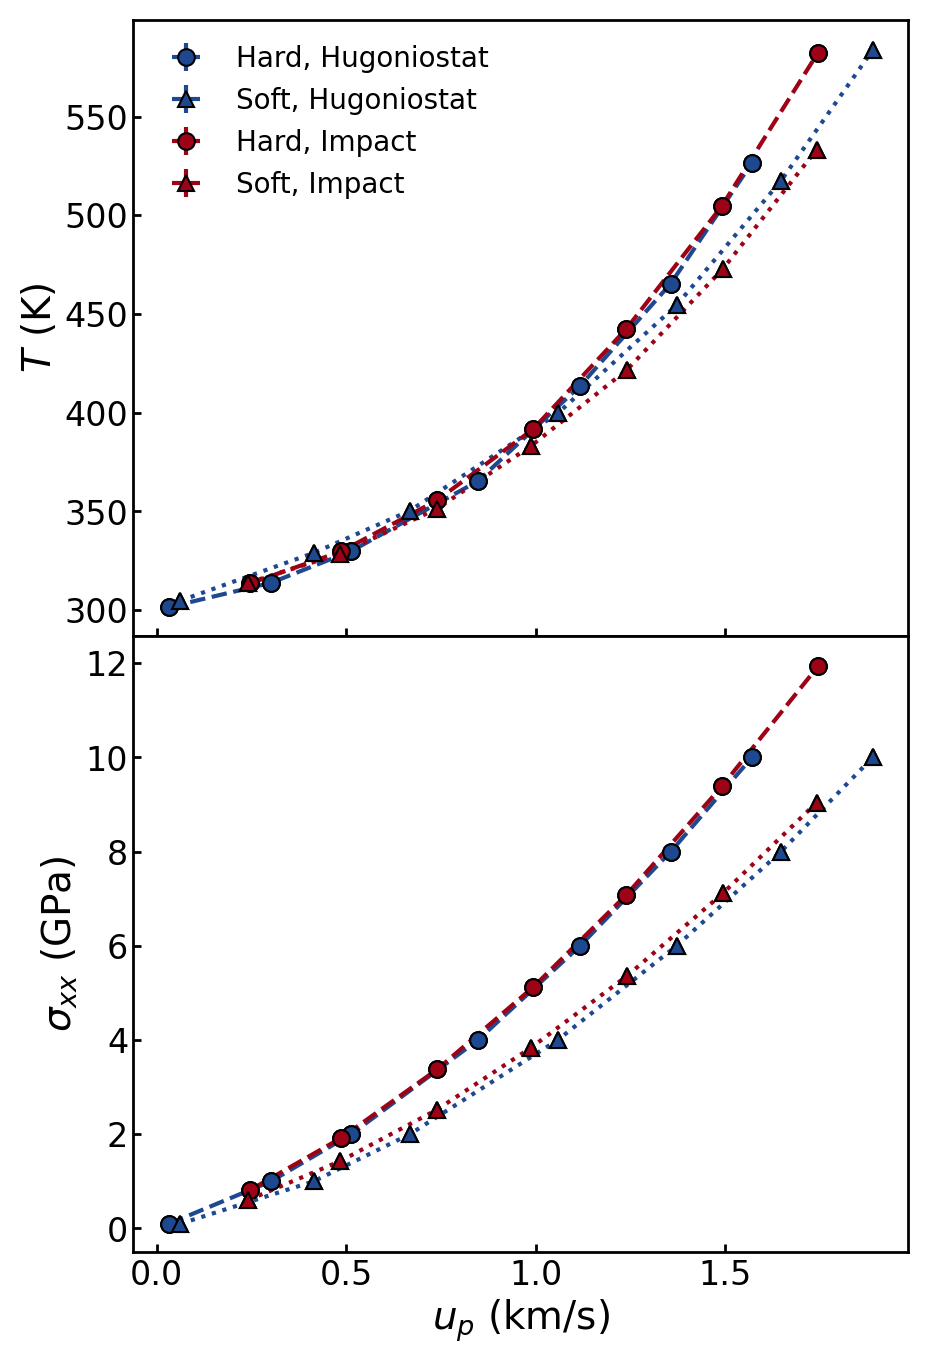

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

# NPHug
data = np.load('data/NPHugHugoniots.npy')

## Hard Phase
ax[0].errorbar(data[0,:,3,0], data[0,:,1,0], xerr = data[0,:,3,1], yerr = data[0,:,1,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Hard, Hugoniostat', zorder = 2)
ax[0].errorbar(data[0,:,3,0], data[0,:,1,0], xerr = data[0,:,3,1], yerr = data[0,:,1,1], marker = 'o', mec = 'k', ls = '--', c = 'xkcd:cobalt', zorder = 1)
ax[1].errorbar(data[0,:,3,0], data[0,:,0,0], xerr = data[0,:,3,1], yerr = data[0,:,0,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)
ax[1].errorbar(data[0,:,3,0], data[0,:,0,0], xerr = data[0,:,3,1], yerr = data[0,:,0,1], marker = 'o', mec = 'k', ls = '--', c = 'xkcd:cobalt', zorder = 1)

## Soft Phase
ax[0].errorbar(data[1,:,3,0], data[1,:,1,0], xerr = data[1,:,3,1], yerr = data[1,:,1,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft, Hugoniostat', zorder = 2)
ax[0].errorbar(data[1,:,3,0], data[1,:,1,0], xerr = data[1,:,3,1], yerr = data[1,:,1,1], marker = '^', mec = 'k', ls = 'dotted', c = 'xkcd:cobalt', zorder = 1)
ax[1].errorbar(data[1,:,3,0], data[1,:,0,0], xerr = data[1,:,3,1], yerr = data[1,:,0,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)
ax[1].errorbar(data[1,:,3,0], data[1,:,0,0], xerr = data[1,:,3,1], yerr = data[1,:,0,1], marker = '^', mec = 'k', ls = 'dotted', c = 'xkcd:cobalt', zorder = 1)

# Impact
data = np.load('data/impactHugoniotsE.npy')

## Hard Phase
ax[0].errorbar(data[0,3,:,0], data[0,0,:,0], xerr = data[0,3,:,1], yerr = data[0,0,:,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:carmine', label = 'Hard, Impact', zorder = 2)
ax[0].errorbar(data[0,3,:,0], data[0,0,:,0], xerr = data[0,3,:,1], yerr = data[0,0,:,1], marker = 'o', mec = 'k', ls = '--', c = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[0,3,:,0], data[0,1,:,0], xerr = data[0,3,:,1], yerr = data[0,1,:,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[0,3,:,0], data[0,1,:,0], xerr = data[0,3,:,1], yerr = data[0,1,:,1], marker = 'o', mec = 'k', ls = '--', c = 'xkcd:carmine', zorder = 1)

## Soft Phase
ax[0].errorbar(data[1,3,:,0], data[1,0,:,0], xerr = data[1,3,:,1], yerr = data[1,0,:,1], marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', label = 'Soft, Impact', zorder = 2)
ax[0].errorbar(data[1,3,:,0], data[1,0,:,0], xerr = data[1,3,:,1], yerr = data[1,0,:,1], marker = '^', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[1,3,:,0], data[1,1,:,0], xerr = data[1,3,:,1], yerr = data[1,1,:,1], marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[1,3,:,0], data[1,1,:,0], xerr = data[1,3,:,1], yerr = data[1,1,:,1], marker = '^', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)

###

ax[1].set_xlabel("$u_p$ (km/s)")
ax[0].set_ylabel("$T$ (K)"); ax[1].set_ylabel("$\sigma_{xx}$ (GPa)")
ax[0].legend()

plt.subplots_adjust(hspace=0)

# Figure 10

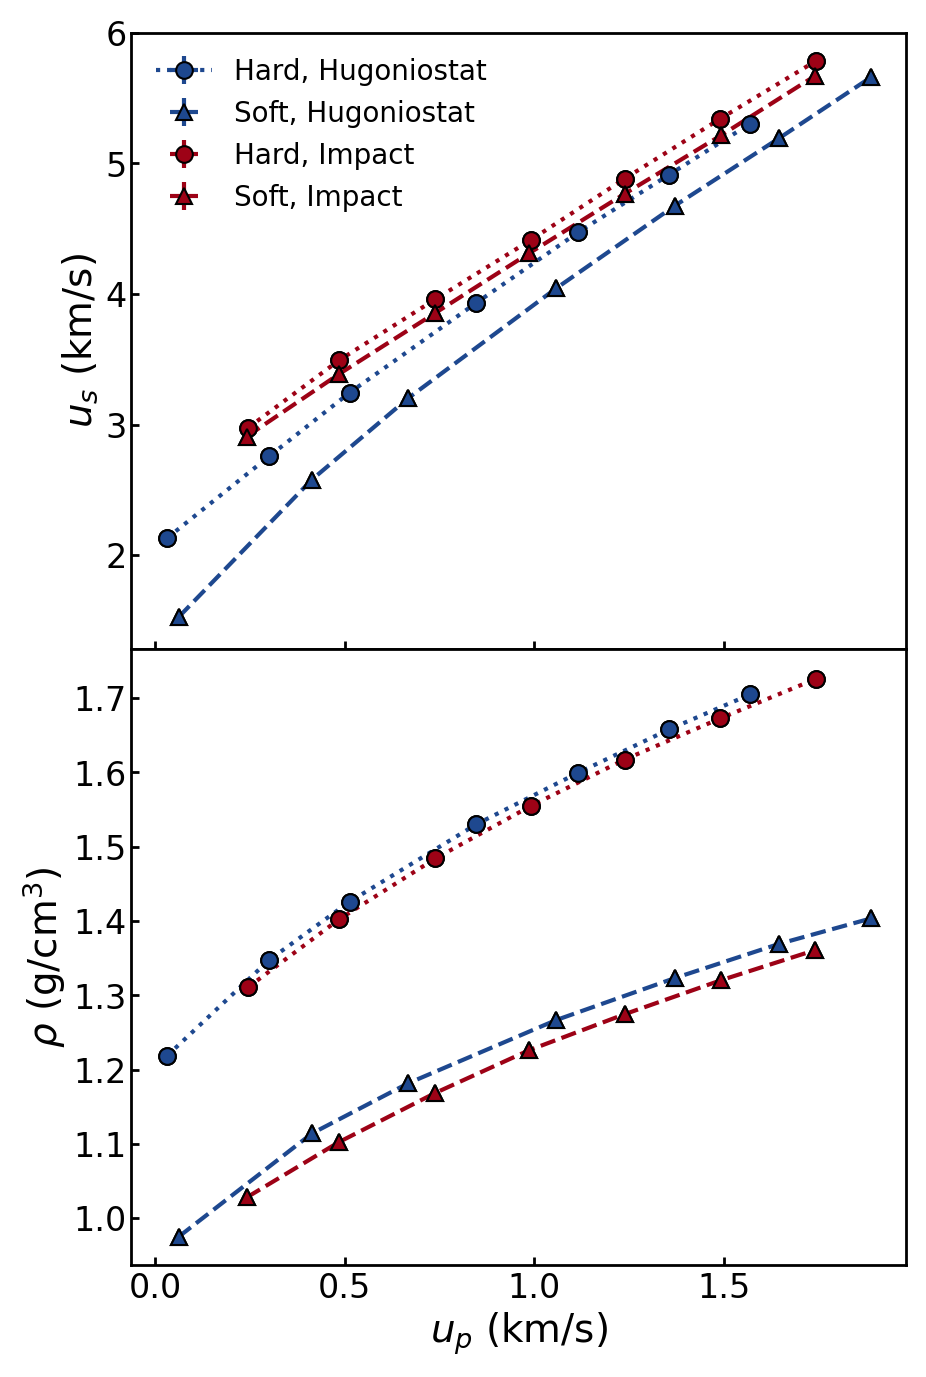

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

rho0h = 1.2004; rho0s = 0.9352 # Quiescent densities in g/cm^3

# NPHug
data = np.load('data/NPHugHugoniots.npy')

## Hard Phase
ax[0].errorbar(data[0,:,3,0], data[0,:,4,0], xerr = data[0,:,3,1], yerr = data[0,:,4,1], marker = 'o', mec = 'k', ls = 'dotted', c = 'xkcd:cobalt', label = 'Hard, Hugoniostat', zorder = 2)
ax[0].errorbar(data[0,:,3,0], data[0,:,4,0], xerr = data[0,:,3,1], yerr = data[0,:,4,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 1)
ax[1].errorbar(data[0,:,3,0], rho0h/data[0,:,2,0], xerr = data[0,:,3,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)
ax[1].errorbar(data[0,:,3,0], rho0h/data[0,:,2,0], xerr = data[0,:,3,1], marker = 'o', mec = 'k', ls = 'dotted', c = 'xkcd:cobalt', zorder = 1)

## Soft Phase
ax[0].errorbar(data[1,:,3,0], data[1,:,4,0], xerr = data[1,:,3,1], yerr = data[1,:,4,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft, Hugoniostat', zorder = 2)
ax[0].errorbar(data[1,:,3,0], data[1,:,4,0], xerr = data[1,:,3,1], yerr = data[1,:,4,1], marker = '^', mec = 'k', ls = '--', c = 'xkcd:cobalt', zorder = 1)
ax[1].errorbar(data[1,:,3,0], rho0s/data[1,:,2,0], xerr = data[1,:,3,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', zorder = 2)
ax[1].errorbar(data[1,:,3,0], rho0s/data[1,:,2,0], xerr = data[1,:,3,1], marker = '^', mec = 'k', ls = '--', c = 'xkcd:cobalt', zorder = 1)

# Impact
data = np.load('data/impactHugoniotsE.npy')
data2 = np.load('data/impactHugoniots.npy')

## Hard Phase
ax[0].errorbar(data[0,3,:,0], data2[0,4], xerr = data[0,3,:,1], yerr = 0, marker = 'o', mec = 'k', ls = '', color = 'xkcd:carmine', label = 'Hard, Impact', zorder = 2)
ax[0].errorbar(data[0,3,:,0], data2[0,4], xerr = data[0,3,:,1], yerr = 0, marker = 'o', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[0,3,:,0], data[0,2,:,0], xerr = data[0,3,:,1], yerr = data[0,2,:,1], marker = 'o', mec = 'k', ls = '', color = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[0,3,:,0], data[0,2,:,0], xerr = data[0,3,:,1], yerr = data[0,2,:,1], marker = 'o', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)

## Soft Phase
ax[0].errorbar(data[1,3,:,0], data2[1,4], xerr = data[1,3,:,1], yerr = 0, marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', label = 'Soft, Impact', zorder = 2)
ax[0].errorbar(data[1,3,:,0], data2[1,4], xerr = data[1,3,:,1], yerr = 0, marker = '^', mec = 'k', ls = '--', color = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[1,3,:,0], data[1,2,:,0], xerr = data[1,3,:,1], yerr = data[1,2,:,1], marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[1,3,:,0], data[1,2,:,0], xerr = data[1,3,:,1], yerr = data[1,2,:,1], marker = '^', mec = 'k', ls = '--', color = 'xkcd:carmine', zorder = 1)

###

ax[1].set_xlabel("$u_p$ (km/s)")
ax[0].set_ylabel("$u_s$ (km/s)"); ax[1].set_ylabel(r"$\rho$ (g/cm$^3$)")
ax[0].legend()

plt.subplots_adjust(hspace=0)

# Figure 11

/tmp/ipykernel_2836729/1687652989.py:5: RuntimeWarning: invalid value encountered in log
  y = A - sigV*np.log(1+t*tD/sigV)


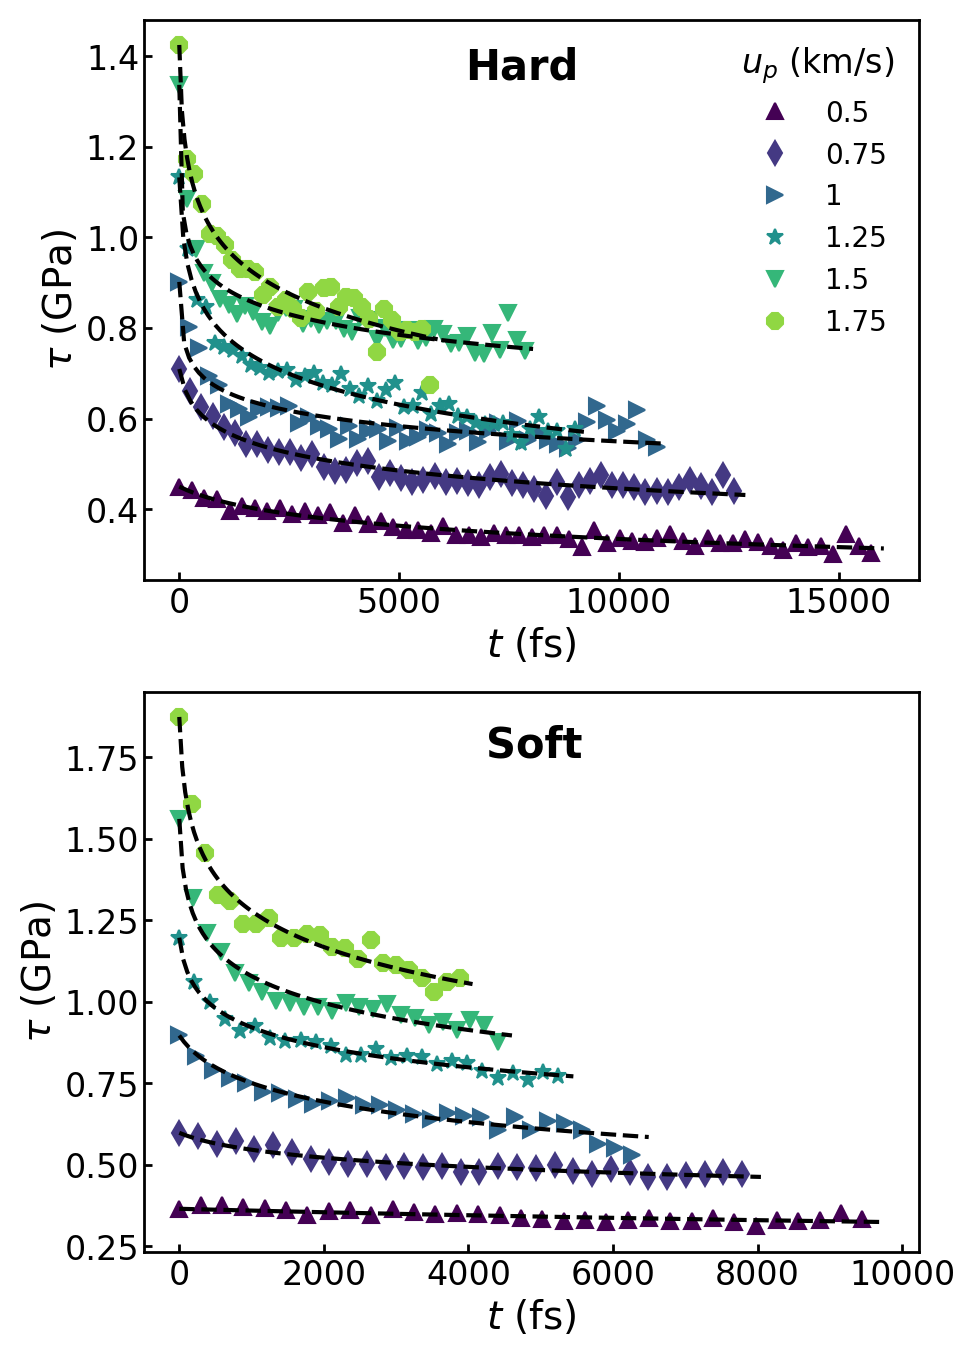

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16))

# Guiu/Pratt Expression
def log(t, sigV, tD):
    y = A - sigV*np.log(1+t*tD/sigV)
    return y

ups = [0.5, 0.75, 1, 1.25, 1.5, 1.75]
symbols = ['^', 'd', '>', '*', 'v', '8']

cutoff = 5

for i in range(len(ups)):
    # Hard Phase
    data = np.load('data/Impact/hard/{:s}/binnedTau.npy'.format(str(ups[i])))
    us = np.load('data/impactHugoniots.npy')[0,4,i+1]/100 # us in A/fs
    data[0] *= 10 # X in A
    t = data[0]/us # t in fs

    ax[0].plot(t[:-cutoff], data[2,:-cutoff], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])), zorder = 1)

    ## Curve Fitting
    A = data[2,0]
    popt, pcov = curve_fit(log, t[:-cutoff], data[2,:-cutoff])
    x = np.linspace(t[0], t[-cutoff], 100); y = log(x,*popt)
    ax[0].plot(x, y, ls = '--', c = 'k')


    # Soft Phase
    data = np.load('data/Impact/soft/{:s}/binnedTau.npy'.format(str(ups[i])))
    us = np.load('data/impactHugoniots.npy')[1,4,i+1]/100 # us in A/fs
    data[0] *= 10 # X in A
    t = data[0]/us # t in fs

    ax[1].plot(t[:-cutoff], data[2,:-cutoff], marker = symbols[i], ls = '', c = cm.viridis(i/len(ups)), label = '{:s}'.format(str(ups[i])), zorder = 1)

    ## Curve Fitting
    A = data[2,0]
    popt, pcov = curve_fit(log, t[:-cutoff], data[2,:-cutoff])
    x = np.linspace(t[0], t[-cutoff], 100); y = log(x,*popt)
    ax[1].plot(x, y, ls = '--', c = 'k')

###

ax[0].text(6500, 1.35, 'Hard', fontsize = 30, weight='bold')
ax[1].text(4250, 1.75, 'Soft', fontsize = 30, weight='bold')

ax[0].set_xlabel('$t$ (fs)'); ax[1].set_xlabel('$t$ (fs)')
ax[0].set_ylabel(r'$\tau$ (GPa)'); ax[1].set_ylabel(r'$\tau$ (GPa)')
ax[0].legend(title = '$u_p$ (km/s)')

# Figure 12

/tmp/ipykernel_2836729/776605552.py:5: RuntimeWarning: invalid value encountered in log
  y = A - sigV*np.log(1+t*tD/sigV)


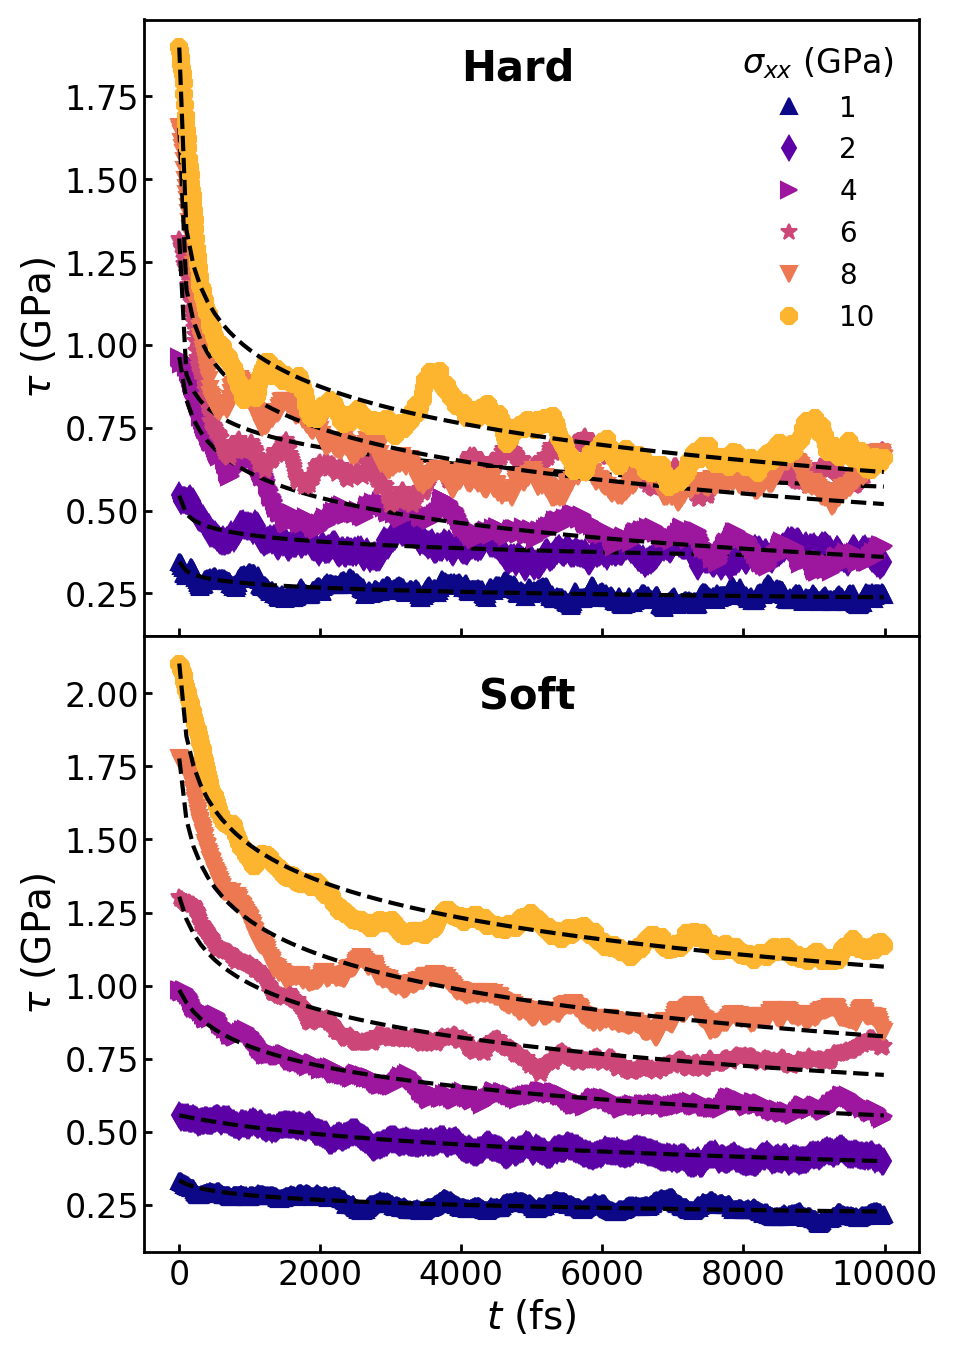

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

# Guiu/Pratt Expression
def log(t, sigV, tD):
    y = A - sigV*np.log(1+t*tD/sigV)
    return y

Ps = np.array([1, 2, 4, 6, 8, 10], dtype = str)
symbols = ['^', 'd', '>', '*', 'v', '8']

for i in range(len(Ps)):
    data = np.load('data/NPHugTau.npy')

    # Hard Phase
    ax[0].plot(data[0,i,0], data[0,i,1], marker = symbols[i], markevery = 1, ls = '', c = cm.plasma(i/len(Ps)), label = '{:s}'.format(Ps[i]))

    ## Curve Fitting
    A = data[0,i,1,0]
    popt, pcov = curve_fit(log, data[0,i,0], data[0,i,1])
    x = np.linspace(data[0,i,0,0], data[0,i,0,-1], 100); y = log(x,*popt)
    ax[0].plot(x, y, ls = '--', c = 'k')


    # Soft Phase
    ax[1].plot(data[1,i,0], data[1,i,1], marker = symbols[i], markevery = 1, ls = '', c = cm.plasma(i/len(Ps)))

    ## Curve Fitting
    A = data[1,i,1,0]
    popt, pcov = curve_fit(log, data[1,i,0], data[1,i,1])
    x = np.linspace(data[1,i,0,0], data[1,i,0,-1], 100); y = log(x,*popt)
    ax[1].plot(x, y, ls = '--', c = 'k')

###

ax[0].text(4000, 1.8, 'Hard', fontsize = 30, weight='bold')
ax[1].text(4250, 1.95, 'Soft', fontsize = 30, weight='bold')

ax[0].set_xlabel('$t$ (fs)'); ax[1].set_xlabel('$t$ (fs)')
ax[0].set_ylabel(r'$\tau$ (GPa)'); ax[1].set_ylabel(r'$\tau$ (GPa)')
ax[0].legend(title = '$\sigma_{xx}$ (GPa)')

plt.subplots_adjust(hspace=0)

# Figure 13

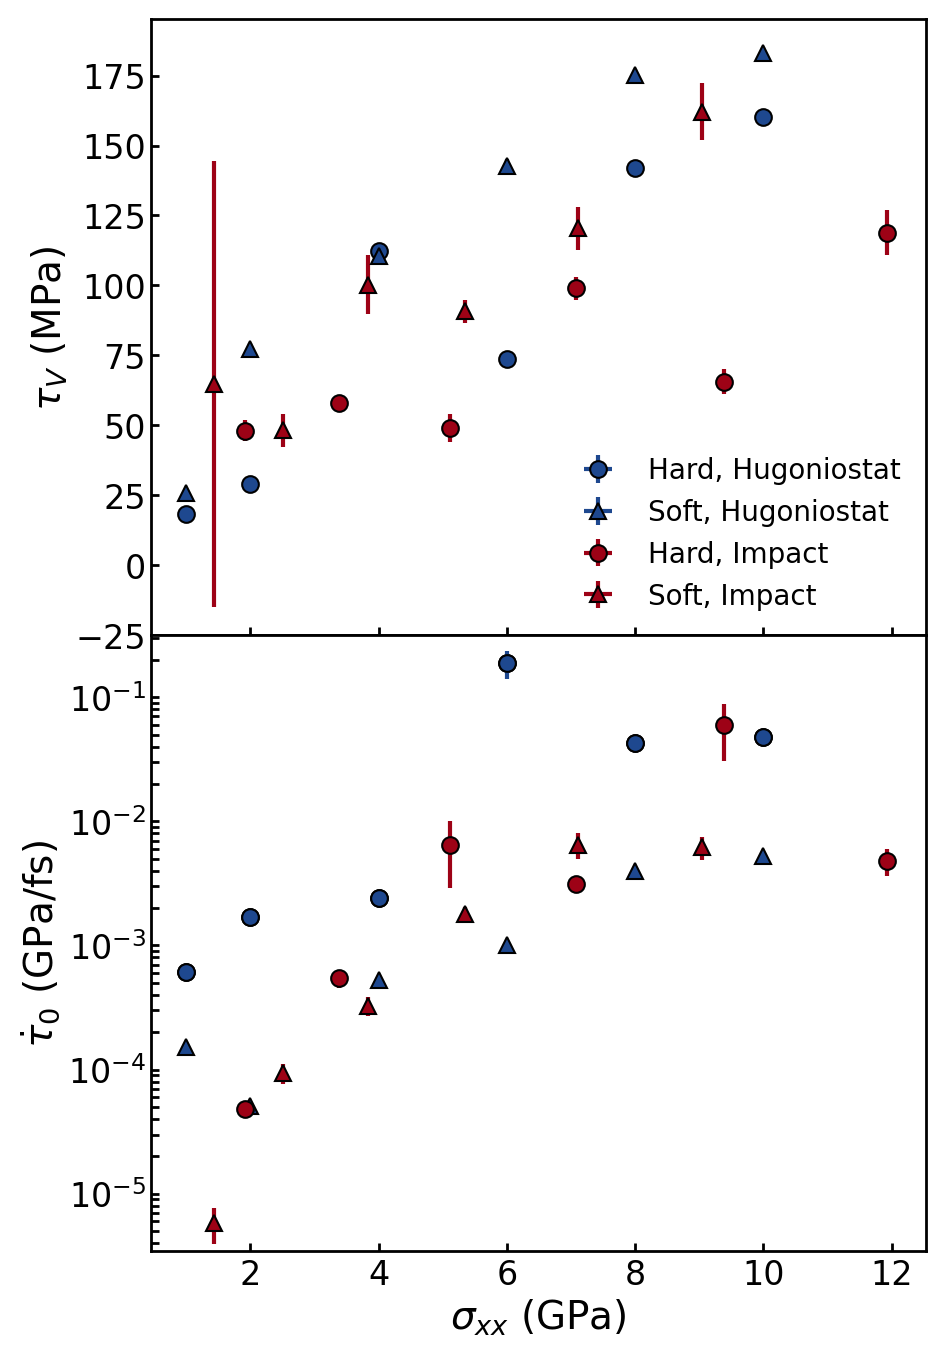

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

fitData = np.load('data/tauFit.npy')

# NPHug
data = np.load('data/NPHugHugoniots.npy')[:,1:]

ax[0].errorbar(data[0,:,0,0], fitData[0,:,1]*1000, xerr = data[0,:,0,1], yerr = fitData[0,:,3]*1000, marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Hard, Hugoniostat')
ax[0].errorbar(data[1,:,0,0], fitData[1,:,1]*1000, xerr = data[1,:,0,1], yerr = fitData[1,:,3]*1000, marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft, Hugoniostat')

ax[1].semilogy(data[0,:,0,0], fitData[0,:,2], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt')
ax[1].errorbar(data[0,:,0,0], fitData[0,:,2], xerr = data[0,:,0,1], yerr = fitData[0,:,4], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt')
ax[1].errorbar(data[1,:,0,0], fitData[1,:,2], xerr = data[1,:,0,1], yerr = fitData[1,:,4], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt')

# Impact
data = np.load('data/impactHugoniotsE.npy')[:,:,1:]

ax[0].errorbar(data[0,1,:,0], fitData[2,:,1]*1000, xerr = data[0,1,:,1], yerr = fitData[2,:,3]*1000, marker = 'o', mec = 'k', ls = '', c = 'xkcd:carmine', label = 'Hard, Impact')
ax[0].errorbar(data[1,1,:,0], fitData[3,:,1]*1000, xerr = data[1,1,:,1], yerr = fitData[3,:,3]*1000, marker = '^', mec = 'k', ls = '', c = 'xkcd:carmine', label = 'Soft, Impact')

ax[1].errorbar(data[0,1,:,0], fitData[2,:,2], xerr = data[0,1,:,1], yerr = fitData[2,:,4], marker = 'o', mec = 'k', ls = '', c = 'xkcd:carmine')
ax[1].errorbar(data[1,1,:,0], fitData[3,:,2], xerr = data[1,1,:,1], yerr = fitData[3,:,4], marker = '^', mec = 'k', ls = '', c = 'xkcd:carmine')

###

ax[1].set_xlabel('$\sigma_{xx}$ (GPa)')
ax[0].set_ylabel(r'$\tau_V$ (MPa)'); ax[1].set_ylabel(r'$\dot{\tau}_0$ (GPa/fs)')
ax[0].legend()

plt.subplots_adjust(hspace=0)

# Figure 14

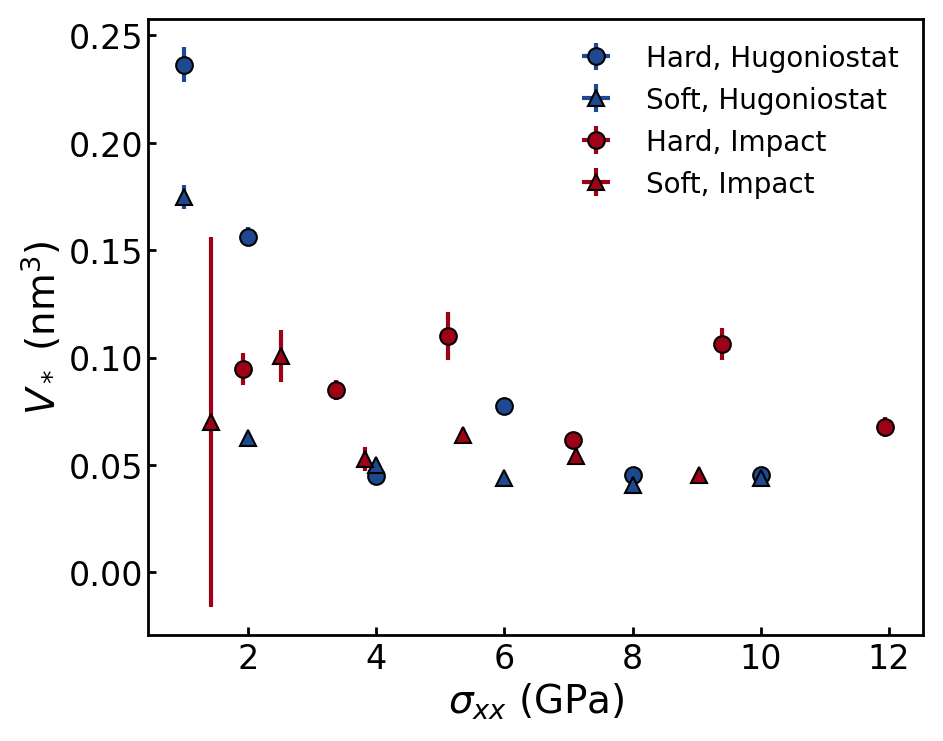

In [ ]:
data = np.load('data/activationVolumes.npy')

# NPHug
data2 = np.load('data/NPHugHugoniots.npy')[:,1:]

plt.errorbar(data2[0,:,0,0], data[0,:,0], xerr = data2[0,:,0,1], yerr = data[0,:,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Hard, Hugoniostat')
plt.errorbar(data2[1,:,0,0], data[1,:,0], xerr = data2[1,:,0,1], yerr = data[1,:,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:cobalt', label = 'Soft, Hugoniostat')

# Impact
data2 = np.load('data/impactHugoniotsE.npy')[:,:,1:]

plt.errorbar(data2[0,1,:,0], data[2,:,0], xerr = data2[0,1,:,1], yerr = data[2,:,1], marker = 'o', mec = 'k', ls = '', c = 'xkcd:carmine', label = 'Hard, Impact')
plt.errorbar(data2[1,1,:,0], data[3,:,0], xerr = data2[1,1,:,1], yerr = data[3,:,1], marker = '^', mec = 'k', ls = '', c = 'xkcd:carmine', label = 'Soft, Impact')

###

plt.xlabel('$\sigma_{xx}$ (GPa)'); plt.ylabel(r'$V_*$ (nm$^3$)')
plt.legend()

# Figure 15

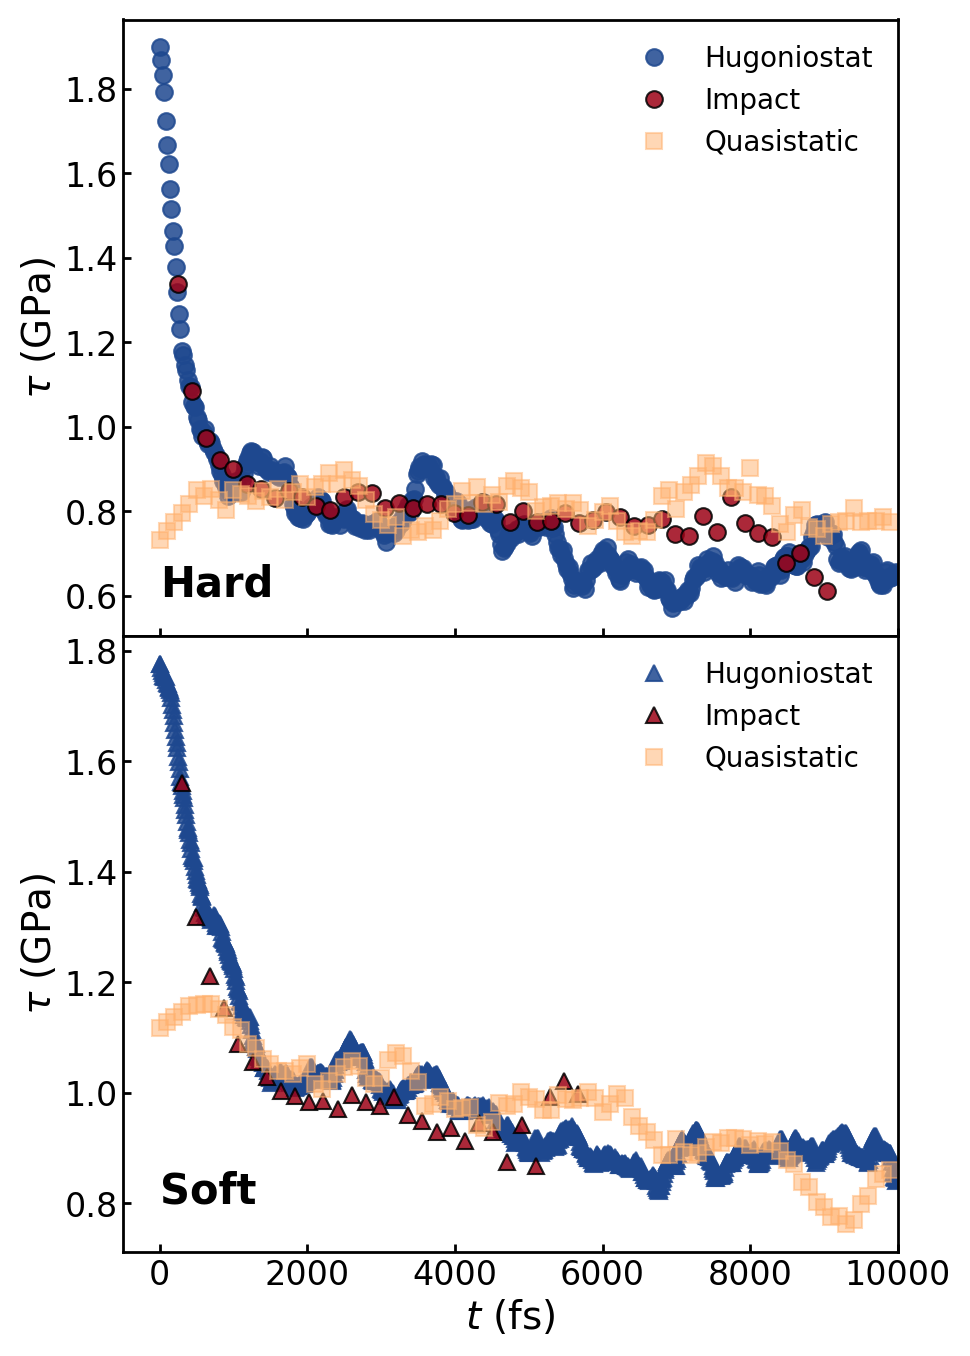

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

# NPHug
data = np.load('data/tauNPHug.npy')
ax[0].plot(data[0,0], data[0,1], marker = 'o', markevery = 2, ls = '', c = 'xkcd:cobalt', label = 'Hugoniostat', alpha = 0.85)
ax[1].plot(data[1,0], data[1,1], marker = '^', markevery = 1, ls = '', c = 'xkcd:cobalt', label = 'Hugoniostat', alpha = 0.85)


# Impact
## Hard
data = np.load('data/Impact/hard/1.5/binnedTau.npy')

us = np.load('data/impactHugoniots.npy')[0,4,-2]/100 # us in A/fs
data[0] *= 10 # X in A
t = data[0]/us # t in fs
C = 250 # Manual horizontal shift factor

ax[0].plot(t + C, data[2], marker = 'o', mec = 'k', linestyle = '', color = 'xkcd:carmine', label = 'Impact', alpha = 0.85)

## Soft
data = np.load('data/Impact/soft/1.5/binnedTau.npy')

us = np.load('data/impactHugoniots.npy')[1,4,-2]/100 # us in A/fs
data[0] *= 10 # X in A
t = data[0]/us # t in fs
C = 300 # Manual horizontal shift factor

ax[1].plot(t + C, data[2], marker = '^', mec = 'k', linestyle = '', color = 'xkcd:carmine', label = 'Impact', alpha = 0.85)


# Quasistatic
data = np.load('data/tauQuasistatic.npy')
ax[0].plot(data[0,0], data[0,1], marker = 's', ls = '', c = 'xkcd:apricot', label = 'Quasistatic', alpha = 0.5)
ax[1].plot(data[1,0], data[1,1], marker = 's', ls = '', c = 'xkcd:apricot', label = 'Quasistatic', alpha = 0.5)

###

ax[0].text(0, 0.6, 'Hard', fontsize = 30, weight='bold')
ax[1].text(0, 0.8, 'Soft', fontsize = 30, weight='bold')

ax[1].set_xlabel('$t$ (fs)')
ax[0].set_ylabel(r'$\tau$ (GPa)'); ax[1].set_ylabel(r'$\tau$ (GPa)')
ax[0].legend(); ax[1].legend()

plt.xlim(xmax=10000)
plt.subplots_adjust(hspace=0)

# Figure 16

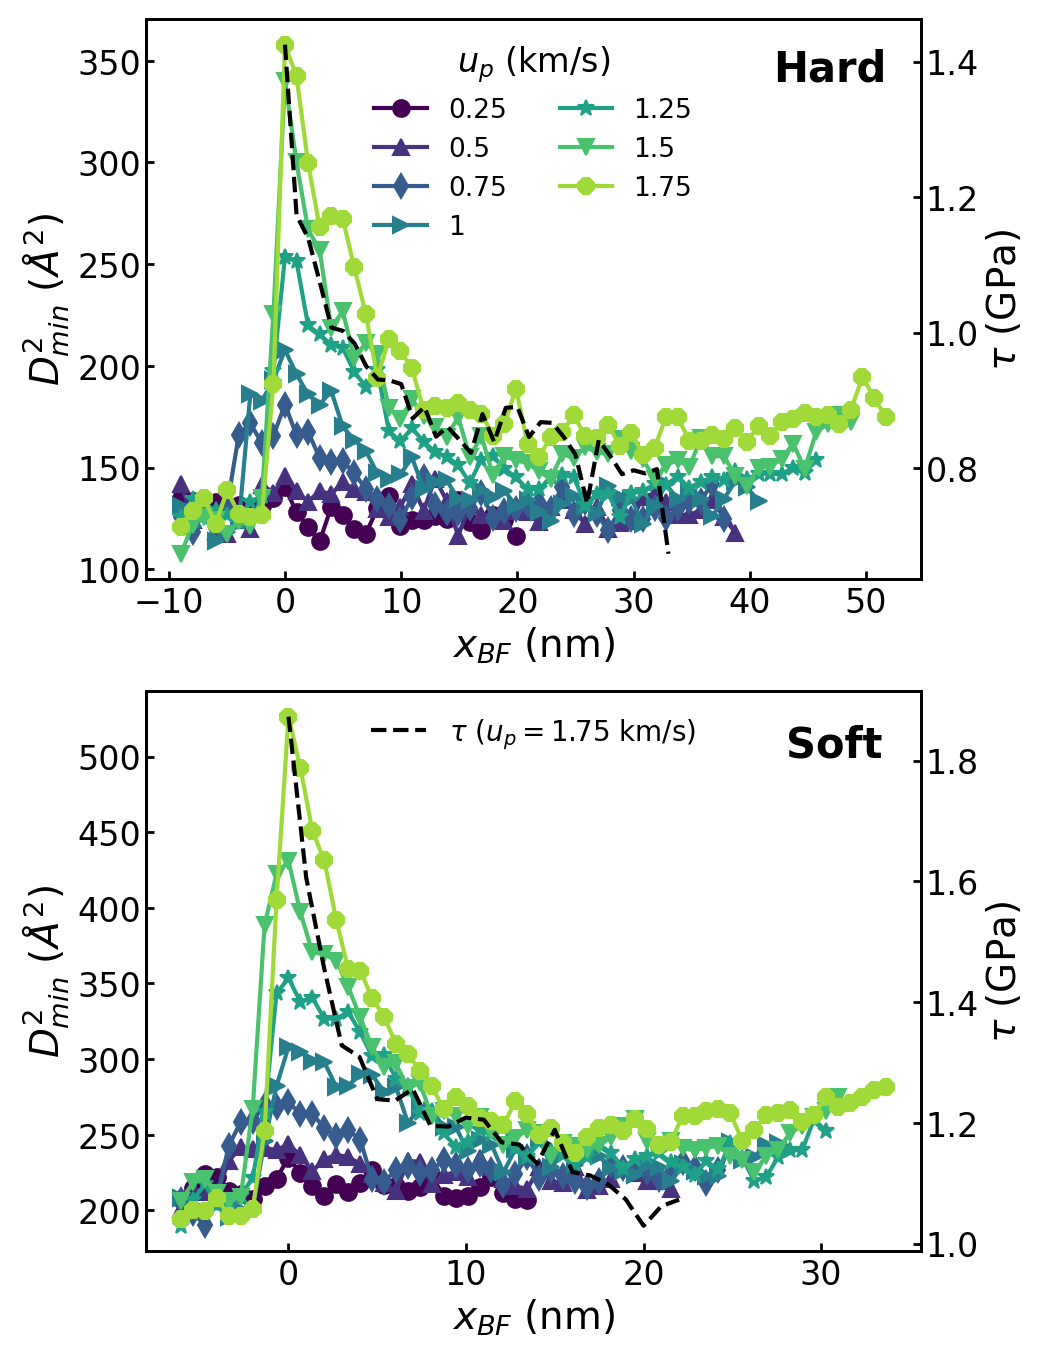

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16))
ax2 = ax[0].twinx(); ax3 = ax[1].twinx()

ups = np.array(['0.25', '0.5', '0.75', '1', '1.25' ,'1.5', '1.75'])
symbols = ['o', '^', 'd', '>', '*', 'v', '8']

# Hard Phase
## NAD
for i in range(len(ups)):
    data = np.loadtxt('data/NAD/hard/NAD{:s}'.format(ups[i]))

    X = data[:,0]/10 # nm
    NAD = data[:,1]

    backCut = np.where(NAD == 0)[0][-1] + 3
    frontCut = np.argmax(NAD)

    X -= X[frontCut]
    X *= -1

    ax[0].plot(X[backCut:frontCut + 10], NAD[backCut:frontCut + 10], marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)), label = ups[i])

## Tau
data = np.load('../hard/201/1.75/data/binnedTau.npy'.format(str(ups[i])))

endCut = 5
ax2.plot(data[0,:-endCut], data[2,:-endCut], marker = '', linestyle = '--', color = 'k', label = r'$\tau$')


# Soft Phase
## NAD
for i in range(len(ups)):
    data = np.loadtxt('data/NAD/soft/NAD{:s}'.format(ups[i]))

    X = data[:,0]/10 # nm
    NAD = data[:,1]

    backCut = np.where(NAD == 0)[0][-1] + 4
    frontCut = np.argmax(NAD)

    X -= X[frontCut]
    X *= -1

    ax[1].plot(X[backCut:frontCut + 10], NAD[backCut:frontCut + 10], marker = symbols[i], ls = '-', c = cm.viridis(i/len(ups)), label = ups[i])

## Tau
data = np.load('../soft/200/{:s}/data/binnedTau.npy'.format(str(ups[i])))

endCut = 5
ax3.plot(data[0,:-endCut], data[2,:-endCut], marker = '', linestyle = '--', color = 'k', label = r'$\tau\ (u_p=1.75$ km/s)')

###

ax[0].text(42, 340, 'Hard', fontsize = 30, weight='bold')
ax[1].text(28, 500, 'Soft', fontsize = 30, weight='bold')

ax[0].set_xlabel('$x_{BF}$ (nm)'); ax[1].set_xlabel('$x_{BF}$ (nm)')
ax[0].set_ylabel('$D^2_{min}\ (\AA^2)$'); ax[1].set_ylabel('$D^2_{min}\ (\AA^2)$')
ax2.set_ylabel(r'$\tau$ (GPa)'); ax3.set_ylabel(r'$\tau$ (GPa)')
ax[0].legend(title = '$u_p$ (km/s)', loc = 'upper center', ncols = 2, fontsize = 19)
ax3.legend(loc = 'upper center')

# Figure 17

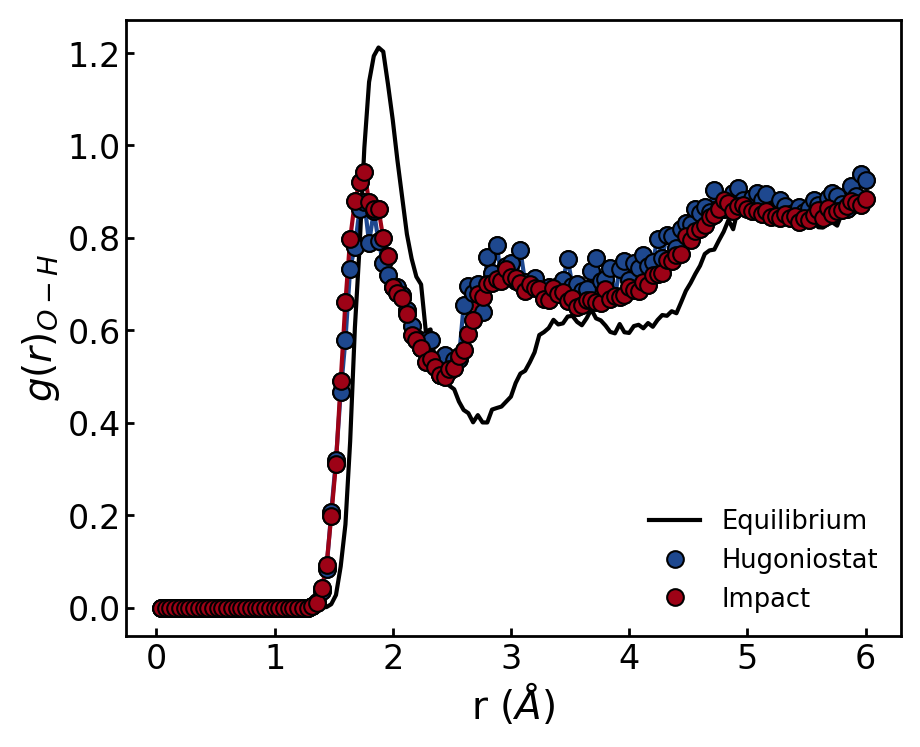

In [73]:
cutoff = -1

# Equilibrium
data = np.load('data/RDF/EqRDF.npy')
plt.plot(data[0], data[1], color = 'black', label = 'Equilibrium')

# NPHug
data = np.load('data/RDF/NPHugRDF.npy')
plt.plot(data[0], data[1], color = 'xkcd:cobalt', marker = 'o', mec = 'k', markersize = 12, ls = '', label = 'Hugoniostat', zorder = 2)
plt.plot(data[0], data[1], color = 'xkcd:cobalt', marker = 'o', mec = 'k', markersize = 12, zorder = 1)

# Impact
data = np.load('data/RDF/ImpactRDF.npy')
plt.plot(data[0], data[1], color = 'xkcd:carmine', marker = 'o', mec = 'k', markersize = markersize, ls = '', label = 'Impact', zorder = 2)
plt.plot(data[0], data[1], color = 'xkcd:carmine', marker = 'o', mec = 'k', markersize = markersize, zorder = 1)

###

plt.xlabel('r ($\AA$)'); plt.ylabel('$g(r)_{O-H}$')
plt.legend(fontsize = 18.5, loc = 'lower right')

# Figure 18

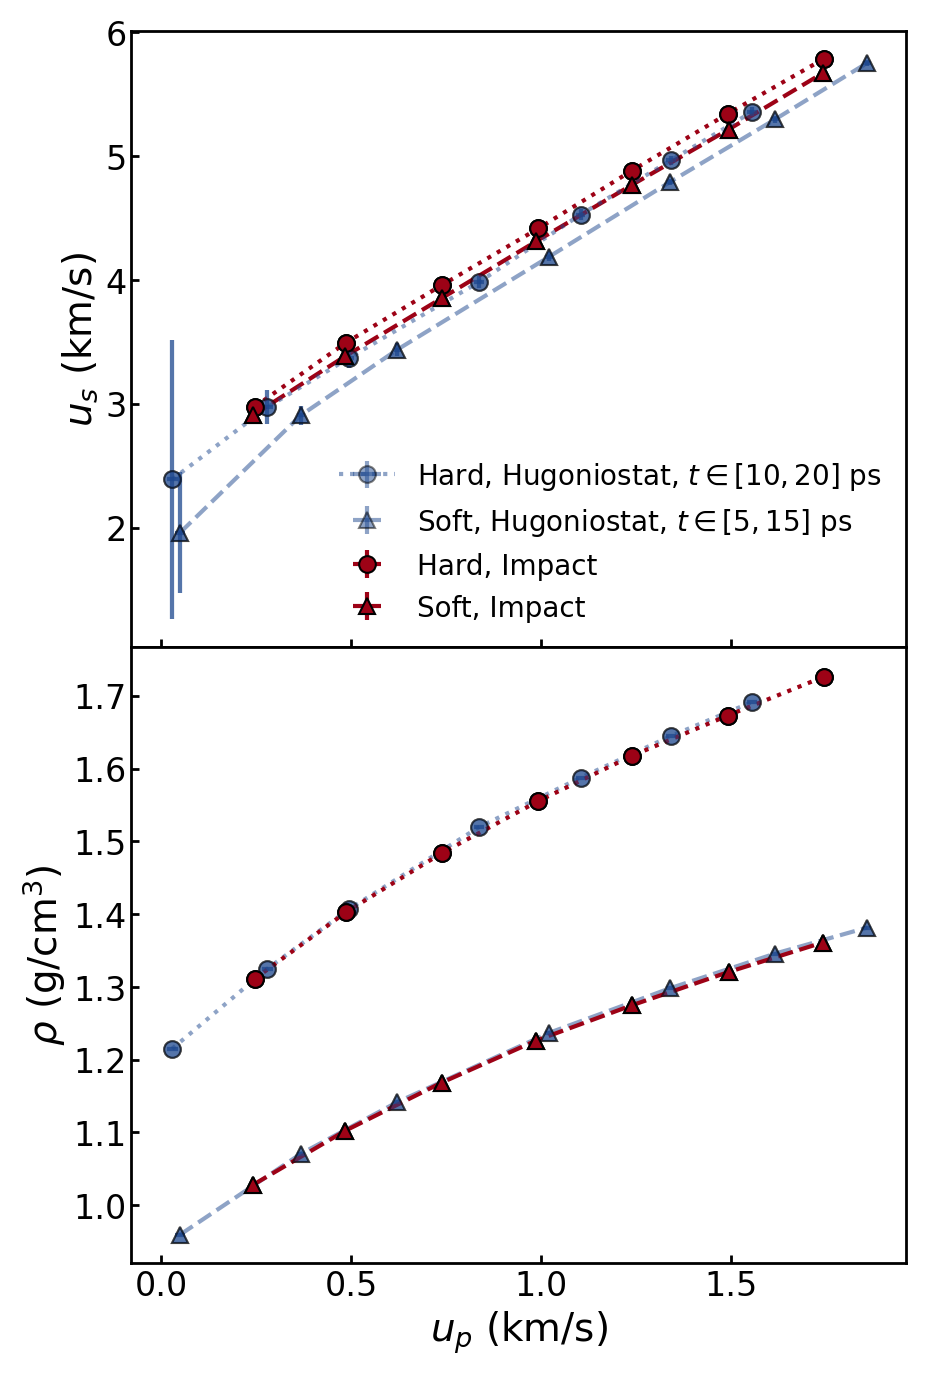

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 16), sharex=True)

rho0h = 1.2004; rho0s = 0.9352 # Quiescent densities in g/cm^3

# NPHug
data = np.load('data/NPHugHugoniots2.npy')

## Hard Phase
ax[0].errorbar(data[0,:,3,0], data[0,:,4,0], xerr = data[0,:,3,1], yerr = data[0,:,4,1], marker = 'o', mec = 'k', color = 'xkcd:cobalt', linestyle = 'dotted', label = 'Hard, Hugoniostat, $t\in[10,20]$ ps', zorder = 2, alpha = 0.5)
ax[0].errorbar(data[0,:,3,0], data[0,:,4,0], xerr = data[0,:,3,1], yerr = data[0,:,4,1], marker = 'o', mec = 'k', color = 'xkcd:cobalt', linestyle = '', zorder = 1, alpha = 0.5)
ax[1].errorbar(data[0,:,3,0], rho0h/data[0,:,2,0], xerr = data[0,:,3,1], marker = 'o', mec = 'k', color = 'xkcd:cobalt', linestyle = '', zorder = 2, alpha = 0.5)
ax[1].errorbar(data[0,:,3,0], rho0h/data[0,:,2,0], xerr = data[0,:,3,1], marker = 'o', mec = 'k', color = 'xkcd:cobalt', linestyle = 'dotted', zorder = 1, alpha = 0.5)

## Soft Phase
ax[0].errorbar(data[1,:,3,0], data[1,:,4,0], xerr = data[1,:,3,1], yerr = data[1,:,4,1], marker = '^', mec = 'k', color = 'xkcd:cobalt', linestyle = '', label = 'Soft, Hugoniostat, $t\in[5,15]$ ps', zorder = 2, alpha = 0.5)
ax[0].errorbar(data[1,:,3,0], data[1,:,4,0], xerr = data[1,:,3,1], yerr = data[1,:,4,1], marker = '^', mec = 'k', color = 'xkcd:cobalt', linestyle = '--', zorder = 1, alpha = 0.5)
ax[1].errorbar(data[1,:,3,0], rho0s/data[1,:,2,0], xerr = data[1,:,3,1], marker = '^', mec = 'k', color = 'xkcd:cobalt', linestyle = '', zorder = 2, alpha = 0.5)
ax[1].errorbar(data[1,:,3,0], rho0s/data[1,:,2,0], xerr = data[1,:,3,1], marker = '^', mec = 'k', color = 'xkcd:cobalt', linestyle = '--', zorder = 1, alpha = 0.5)


# Impact
data = np.load('data/impactHugoniotsE.npy')
data2 = np.load('data/impactHugoniots.npy')

## Hard Phase
ax[0].errorbar(data[0,3,:,0], data2[0,4], xerr = data[0,3,:,1], yerr = 0, marker = 'o', mec = 'k', ls = '', color = 'xkcd:carmine', label = 'Hard, Impact', zorder = 2)
ax[0].errorbar(data[0,3,:,0], data2[0,4], xerr = data[0,3,:,1], yerr = 0, marker = 'o', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[0,3,:,0], data[0,2,:,0], xerr = data[0,3,:,1], yerr = data[0,2,:,1], marker = 'o', mec = 'k', ls = '', color = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[0,3,:,0], data[0,2,:,0], xerr = data[0,3,:,1], yerr = data[0,2,:,1], marker = 'o', mec = 'k', ls = 'dotted', color = 'xkcd:carmine', zorder = 1)

## Soft Phase
ax[0].errorbar(data[1,3,:,0], data2[1,4], xerr = data[1,3,:,1], yerr = 0, marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', label = 'Soft, Impact', zorder = 2)
ax[0].errorbar(data[1,3,:,0], data2[1,4], xerr = data[1,3,:,1], yerr = 0, marker = '^', mec = 'k', ls = '--', color = 'xkcd:carmine', zorder = 1)
ax[1].errorbar(data[1,3,:,0], data[1,2,:,0], xerr = data[1,3,:,1], yerr = data[1,2,:,1], marker = '^', mec = 'k', ls = '', color = 'xkcd:carmine', zorder = 2)
ax[1].errorbar(data[1,3,:,0], data[1,2,:,0], xerr = data[1,3,:,1], yerr = data[1,2,:,1], marker = '^', mec = 'k', ls = '--', color = 'xkcd:carmine', zorder = 1)

###

ax[1].set_xlabel("$u_p$ (km/s)")
ax[0].set_ylabel("$u_s$ (km/s)"); ax[1].set_ylabel(r"$\rho$ (g/cm$^3$)")
ax[0].legend()

plt.subplots_adjust(hspace=0)